In [1]:
import torch
import sys
from pathlib import Path

project_root = Path(r"c:\Users\chem-bras5436\Documents\ml_mp_movements")
sys.path.insert(0, str(project_root))

from model.custom_unet import CustomUNet
from model.model import EventDetector

In [2]:
n_channels = 1
feat_channels = 3
backbone = CustomUNet(n_channels=n_channels, n_classes=feat_channels)
model = EventDetector(backbone=backbone, feat_channels=feat_channels)

In [3]:
backbone = CustomUNet(n_channels=n_channels, n_classes=feat_channels)
model = EventDetector(backbone=backbone, feat_channels=feat_channels)

dummy_input = torch.randn(64, n_channels, 8, 59, 150)  # (N, C, T, H, W)


(dot.exe:5772): Pango-WARNING **: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


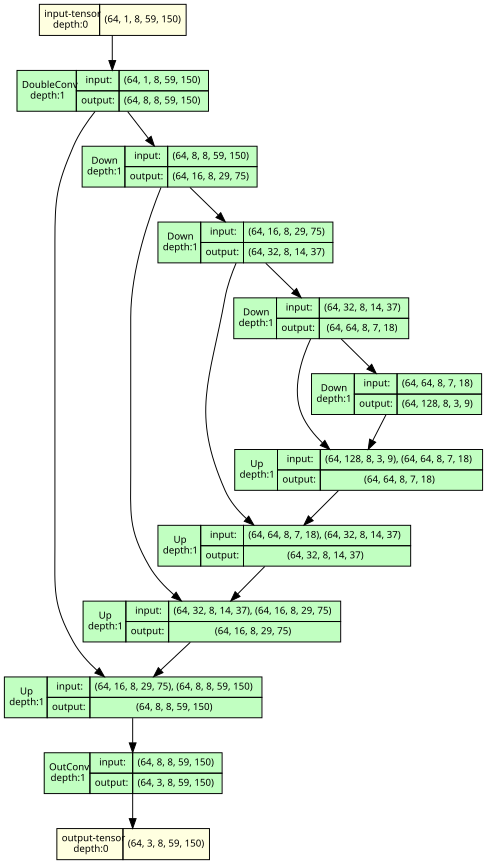

In [15]:
from torchview import draw_graph

graph = draw_graph(
    backbone,
    input_data=dummy_input,
    depth=1,          # 1 = only top-level modules: backbone, heatmap_head, offset_head, orientation_head
    expand_nested=False,
    graph_dir='TB',
    device='meta'
)
graph.visual_graph


(dot.exe:14656): Pango-WARNING **: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


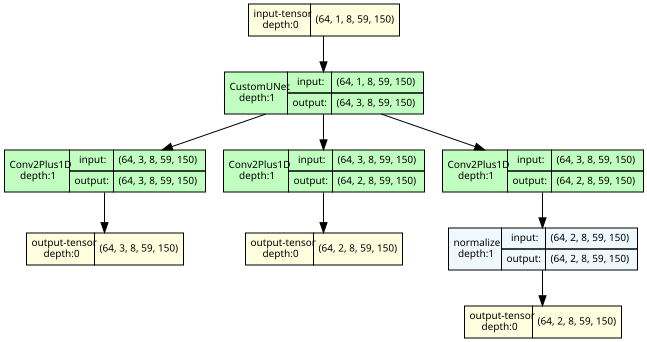

In [14]:
graph = draw_graph(
    model,
    input_data=dummy_input,
    depth=1,          # 1 = only top-level modules: backbone, heatmap_head, offset_head, orientation_head
    expand_nested=False,
    graph_dir='TB',
    device='meta'
)
graph.visual_graph

In [4]:
class TupleWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        out = self.model(x)
        return out["heatmap"], out["offset"], out["orientation"]

In [5]:
traced_model = TupleWrapper(model)


In [7]:
torch.onnx.export(
    traced_model,
    dummy_input,          # or (dummy_input,) — the example input tensor(s)
    "event_detector.onnx" # output file path
)

C:\Users\chem-bras5436\AppData\Local\Temp\ipykernel_48784\1915958156.py:1: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `TupleWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TupleWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\chem-bras5436\AppData\Local\miniconda3\envs\iscat\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.12.1+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[64,1,8,59,150]>
            ),
            outputs=(
                %"conv3d_38"<FLOAT,[64,3,8,59,150]>,
                %"conv3d_40"<FLOAT,[64,2,8,59,150]>,
                %"div"<FLOAT,[64,2,8,59,150]>
            ),
            initializers=(
                %"model.backbone.inc.double_conv.0.conv2plus1d.0.weight"<FLOAT,[12,1,1,5,5]>{TorchTensor(...)},
                %"model.backbone.inc.double_conv.0.conv2plus1d.3.weight"<FLOAT,[8,12,3,1,1]>{TorchTensor(...)},
                %"model.backbone.inc.double_conv.3.conv2plus1d.0.weight"<FLOAT,[21,8,1,5,5]>{TorchTensor(...)},
                %"model.backbone.inc.double_conv.3.conv2plus1d.3.weight"<FLOAT,[